In [1]:
import os
import sys
sys.path.append((os.path.abspath(os.path.join('..'))))

import torch

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
from jepacartpole.models import VAE
from jepacartpole.config import ConfigVAE

from torchsummary import summary

# Initialize model and display architecture summary
vae_config = ConfigVAE()

model = VAE(vae_config).to(DEVICE)
# model.beta = 10 # manually setting VAE beta to a higher value

input_size = (3, 400, 600)
summary(model, input_size)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 200, 300]             784
              ReLU-2         [-1, 16, 200, 300]               0
            Conv2d-3         [-1, 32, 100, 150]           8,224
              ReLU-4         [-1, 32, 100, 150]               0
            Conv2d-5           [-1, 64, 50, 75]          32,832
              ReLU-6           [-1, 64, 50, 75]               0
            Conv2d-7          [-1, 128, 25, 37]         131,200
              ReLU-8          [-1, 128, 25, 37]               0
           Flatten-9               [-1, 118400]               0
           Linear-10                   [-1, 16]       1,894,416
           Linear-11                   [-1, 16]       1,894,416
           Linear-12                [-1, 29600]         503,200
        Unflatten-13           [-1, 32, 25, 37]               0
  ConvTranspose2d-14           [-1, 16,

# Model Diagnosis

In [3]:
import torch
from torch.utils.data import DataLoader
from jepacartpole.datasets import CartPoleVAEDataset

# create daloader
dataset = CartPoleVAEDataset('../data/vae/vae_data.h5')
dataloader = DataLoader(dataset, batch_size=256, num_workers=2, shuffle=True)

# load model
model.load_state_dict(torch.load('../checkpoints/vae.pth', weights_only=False, map_location=DEVICE ))

<All keys matched successfully>

## 1. Reconstruction Quality

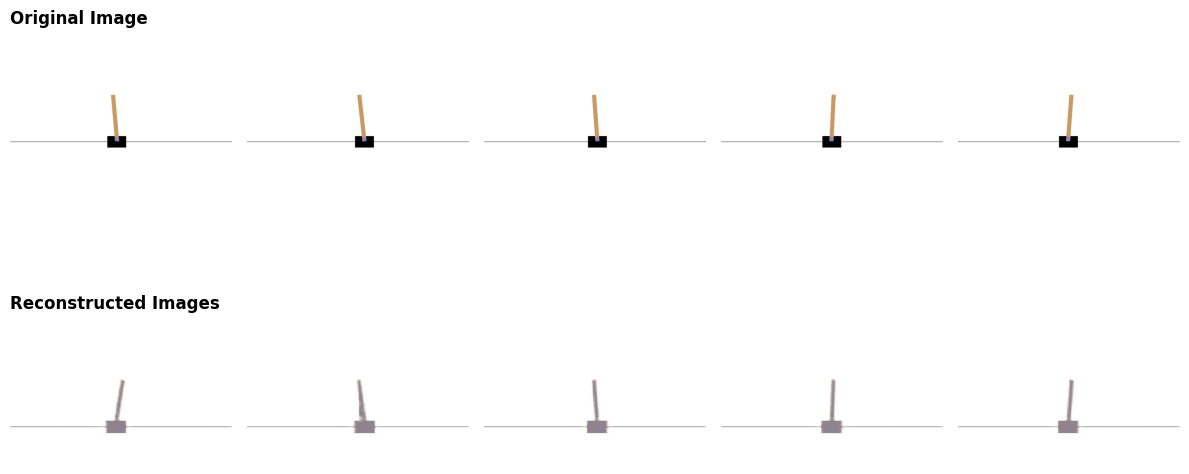

MSE: 0.0023, PSNR: 26.46 dB


In [4]:
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
import numpy as np

def plot_images(original, reconstructed, n=4):
    fig, axes = plt.subplots(2, n, figsize=(12, 7))
    
    for i in range(n):
        axes[0, i].imshow(np.transpose(original[i], axes=(1, 2, 0)), cmap='gray')
        axes[0, i].axis('off')
    axes[0, 0].set_title("Original Image", fontsize=12, fontweight='bold', loc='left')

    for i in range(n):
        axes[1, i].imshow(np.transpose(reconstructed[i], axes=(1, 2, 0)), cmap='gray')
        axes[1, i].axis('off')
    axes[1, 0].set_title("Reconstructed Images", fontsize=12, fontweight='bold', loc='left')
    plt.tight_layout()
    plt.show()


def test_vae(model, dataset, n=3):
    model.eval() 
    # model.train()
    images = next(iter(dataset))[0].to(DEVICE)  # Get a batch of images
    
    with torch.no_grad(): 
        reconstructed, _, _ = model(images)
    indices = torch.randperm(images.size(0))[:n]  # Select random images

    reconstructed = reconstructed.cpu().squeeze().numpy()
    images = images.cpu().squeeze().numpy()
    plot_images(images[indices], reconstructed[indices], n)

    mse = np.mean((images - reconstructed)**2)
    psnr = 20 * np.log10(1.0 / np.sqrt(mse))  # assuming pixel range [0,1]
    print(f"MSE: {mse:.4f}, PSNR: {psnr:.2f} dB")

test_vae(model, dataloader, n=5)

## 2. Latent Space Structure

In [5]:
import gymnasium as gym
from gymnasium.wrappers import AddRenderObservation, TransformObservation

env = gym.make('CartPole-v1', render_mode="rgb_array")
env = AddRenderObservation(env, render_only=True)
print(env.observation_space)

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
error: XDG_RUNTIME_DIR is invalid or not set in the environment.


Box(0, 255, (400, 600, 3), uint8)


ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1342:(snd_func_refer) error evaluating name
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5727:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM default


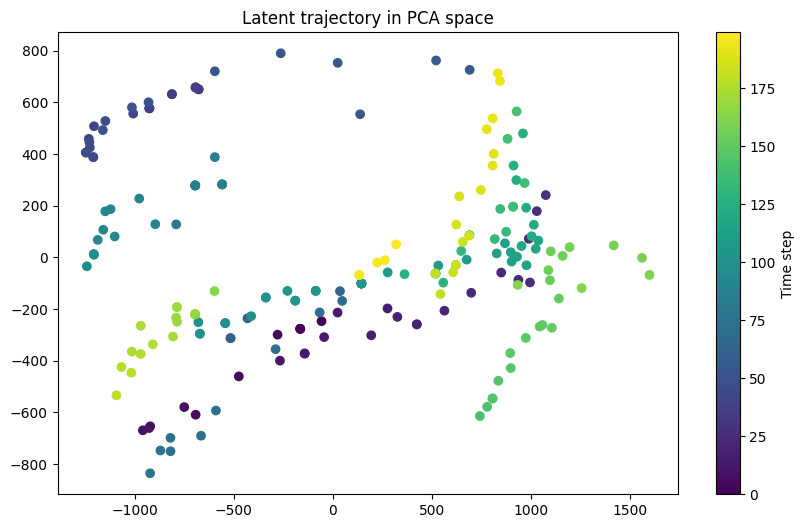

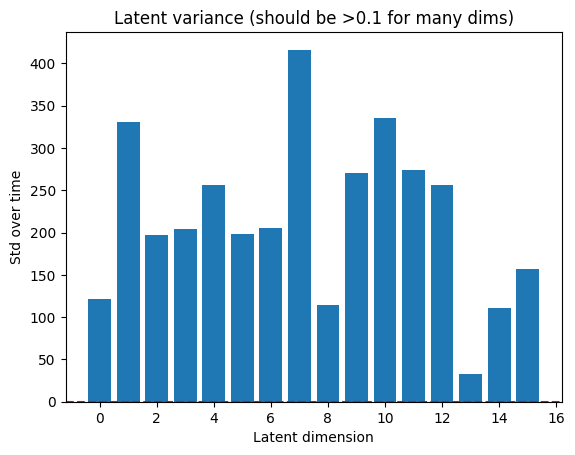

In [6]:
# Get latents for a trajectory
latents_list = []
obs, _ = env.reset()
for step in range(200):
    action = np.random.randint(0, 2)  # or a policy
    obs, reward, done, truncated, _ = env.step(action)

    with torch.no_grad():
        obs_t = torch.FloatTensor(obs).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
        mu, logvar = model.encode(obs_t)
        z = model.reparameterize(mu, logvar)

    latents_list.append(z.cpu().numpy().flatten())
    if done or truncated:
        obs, _ = env.reset()
latents = np.array(latents_list)

# PCA / t-SNE visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
latents_2d = pca.fit_transform(latents)

plt.figure(figsize=(10,6))
plt.scatter(latents_2d[:,0], latents_2d[:,1], c=range(len(latents_2d)), cmap='viridis')
plt.colorbar(label='Time step')
plt.title("Latent trajectory in PCA space")
plt.show()

# Check latent variance collapse
latent_std = latents.std(axis=0)
plt.bar(range(len(latent_std)), latent_std)
plt.xlabel("Latent dimension")
plt.ylabel("Std over time")
plt.title("Latent variance (should be >0.1 for many dims)")
plt.axhline(0.1, color='r', linestyle='--')

## 3. KL Divergence vs Reconstruction Loss

In [7]:
from tqdm import tqdm

def calculate_mean_losses():
    beta = 1

    # During evaluation
    recon_losses = []
    kl_losses = []

    print("device: " + str(DEVICE))
    n_batches = 4 # change to batch

    with torch.no_grad():
        for _ in tqdm(range(n_batches)):
            images, _, _, _ = next(iter(dataloader))
            images = images.to(DEVICE)
            recon, mu, logvar = model(images)
            _, recon_loss, kl_loss = model.loss(recon, images, mu, logvar)
            
            recon_losses.append(recon_loss.item())
            kl_losses.append(kl_loss.item())

    print(f"Avg Recon Loss: {np.mean(recon_losses):.4f}")
    print(f"Avg KL Loss: {np.mean(kl_losses):.4f}")
    print(f"KL / Recon Ratio: {np.mean(kl_losses)/np.mean(recon_losses):.2f}")

calculate_mean_losses()

device: cuda


100%|██████████| 4/4 [00:26<00:00,  6.55s/it]

Avg Recon Loss: 1626.3260
Avg KL Loss: 31.8202
KL / Recon Ratio: 0.02


## Latent Interpolation Smoothness

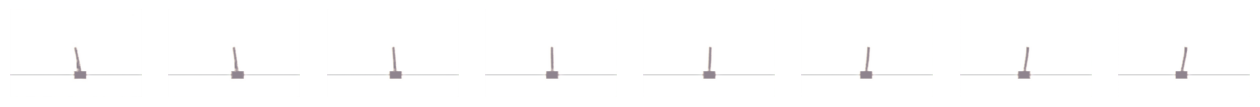

In [8]:
def interpolate(z1, z2, steps=10):
    alphas = np.linspace(0, 1, steps)
    interpolated = []
    for alpha in alphas:
        z = (1-alpha) * z1 + alpha * z2
        with torch.no_grad():
            recon = model.decode(z)
        interpolated.append(recon.cpu().numpy()[0])
    return interpolated

# Pick two very different observations
obs_batch, _, _, _ = next(iter(dataloader))
indices = np.random.choice(len(obs_batch), size=2, replace=False)

obs1, obs2 = obs_batch[indices[0]].to(DEVICE), obs_batch[indices[1]].to(DEVICE)

with torch.no_grad():
    mu1, logvar1 = model.encode(obs1.unsqueeze(0))
    mu2, logvar2 = model.encode(obs2.unsqueeze(0))

    z1 = model.reparameterize(mu1, logvar1)
    z2 = model.reparameterize(mu2, logvar2)

interp_obs = interpolate(z1, z2, steps=8)

# Visualize interpolation
fig, axes = plt.subplots(1, 8, figsize=(16, 3))
for i, img in enumerate(interp_obs):
    axes[i].imshow(img.transpose(1,2,0), cmap='gray')
    axes[i].axis('off')
plt.show()

## Posterior Collapse Test

100%|██████████| 250/250 [05:50<00:00,  1.40s/it]

Active latent dimensions (KL>0.05): 16 / 16


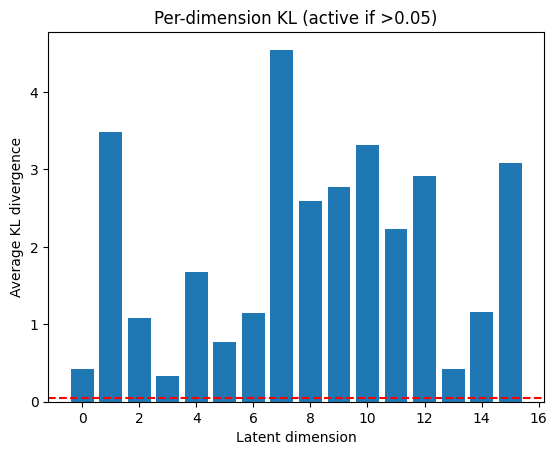

In [9]:
# Compute average KL per dimension
kl_per_dim = []

for images, _, _, _ in tqdm(dataloader):
    obs = images.to(DEVICE)
    with torch.no_grad():
        mu, logvar = model.encode(obs)
        kl_dim = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).mean(dim=0)
    
    kl_per_dim.append(kl_dim.cpu().numpy())

kl_per_dim = np.mean(kl_per_dim, axis=0)
active_dims = (kl_per_dim > 0.05).sum()
print(f"Active latent dimensions (KL>0.05): {active_dims} / {len(kl_per_dim)}")

plt.bar(range(len(kl_per_dim)), kl_per_dim)
plt.xlabel("Latent dimension")
plt.ylabel("Average KL divergence")
plt.title("Per-dimension KL (active if >0.05)")
plt.axhline(0.05, color='r', linestyle='--')